<a href="https://colab.research.google.com/github/Arnav007-python/Car-Price-prediction-/blob/main/CodeAlpha_Car_Price_Prediction_with_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Dataset Loaded Successfully from Google Drive ---
Data Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

--- Running Preprocessing Pipeline ---
Detected Numerical Features: ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']
Detected Categorical

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/tmp/ipykernel_2119/272452679.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=importance_df, palette='viridis')


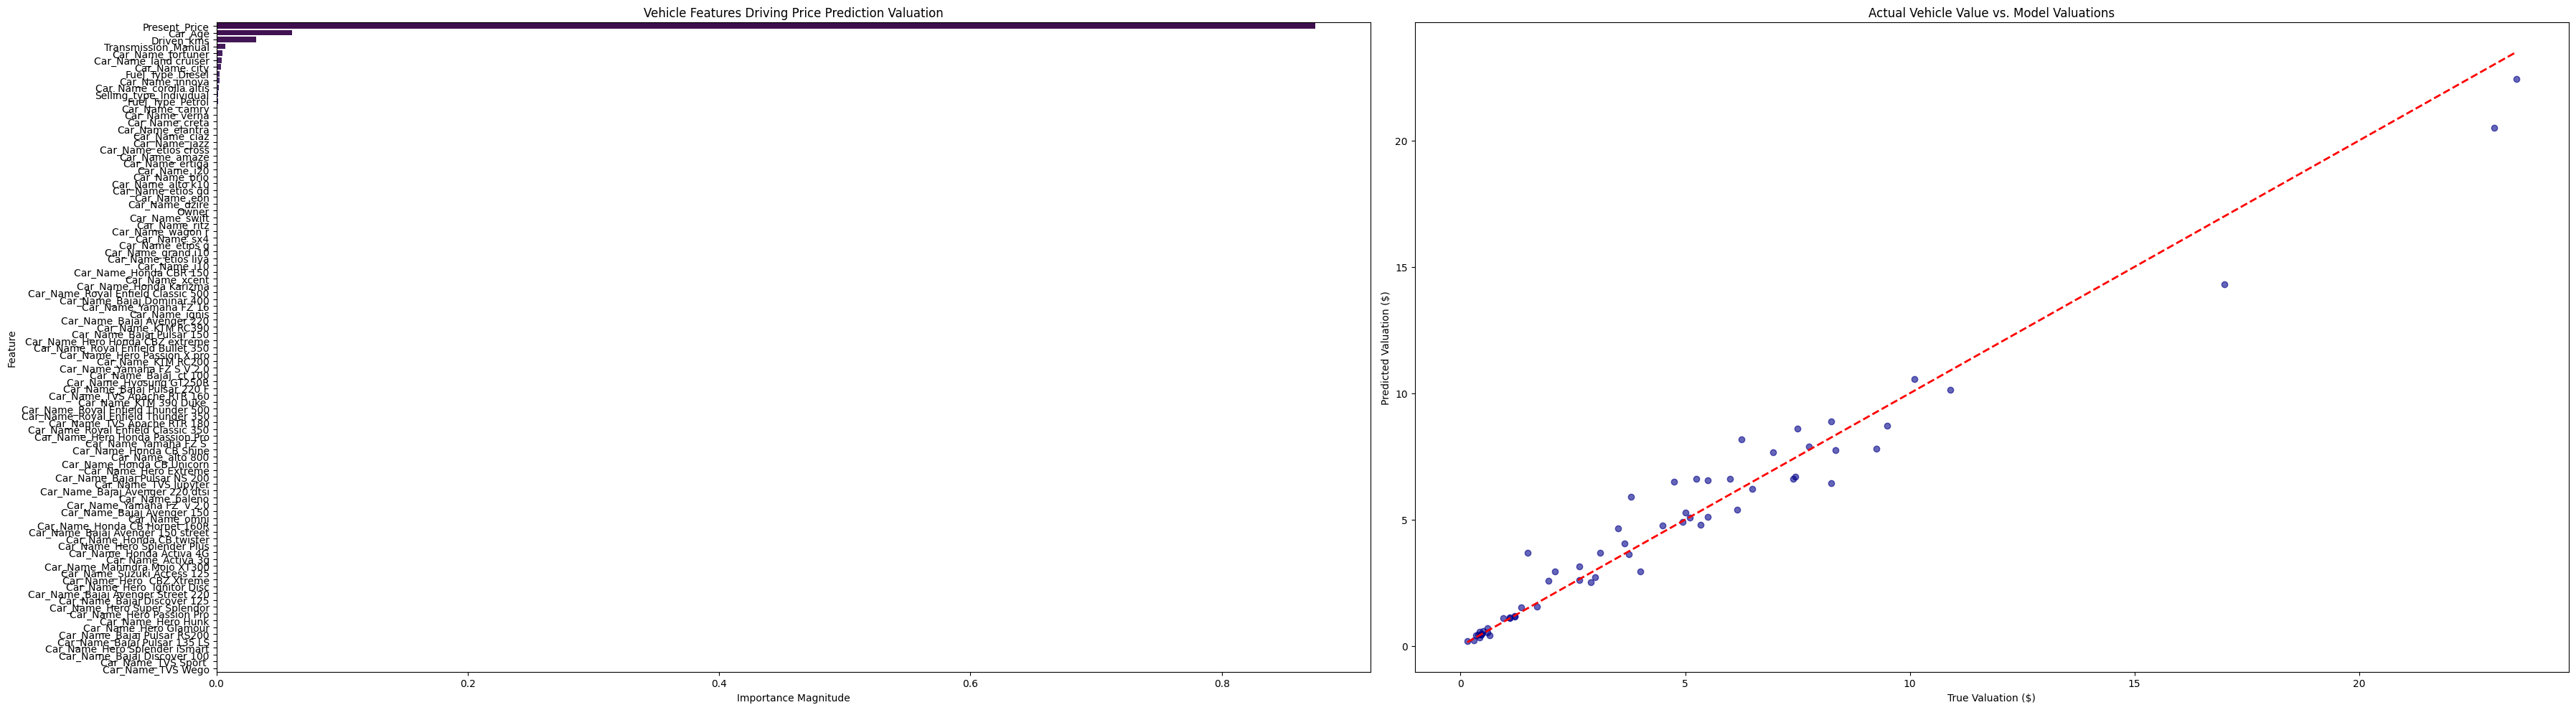

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/CodeA/CarPrice.csv'

try:
    df = pd.read_csv(file_path)
    print("--- Dataset Loaded Successfully from Google Drive ---")
    print(f"Data Shape: {df.shape}")
    print(df.head())
except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'. Double-check the filename, file extension, and folder path in your Google Drive.")


print("\n--- Running Preprocessing Pipeline ---")


num_cols_to_impute = df.select_dtypes(include=[np.number]).columns
for col in num_cols_to_impute:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)


if 'Year' in df.columns:
    current_year = 2026
    df['Car_Age'] = current_year - df['Year']
    df = df.drop(columns=['Year'])


target_col = 'Selling_Price'

X = df.drop(columns=[target_col])
y = df[target_col]


num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Detected Numerical Features: {num_features}")
print(f"Detected Categorical Features: {cat_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

# 80/20 train/test structural split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("\n--- Training Machine Learning Regression Pipeline ---")


model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42))
])

# Fit data to train the model
model_pipeline.fit(X_train, y_train)
print("Pipeline optimization executed successfully.")


print("\n--- Performance Metrics ---")
y_pred = model_pipeline.predict(X_test)

print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R-squared Accuracy (R²): {r2_score(y_test, y_pred):.4f}")

# Extract relative feature weight data
cat_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
try:
    encoded_cat_features = list(cat_encoder.get_feature_names_out(cat_features))
except:
    encoded_cat_features = [] # Fallback if no categorical variables exist

all_features = num_features + encoded_cat_features
importances = model_pipeline.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({'Feature': all_features, 'Weight': importances}).sort_values(by='Weight', ascending=False)


plt.figure(figsize=(36, 10))

# Plot 1: Feature Importances
plt.subplot(1, 2, 1)
sns.barplot(x='Weight', y='Feature', data=importance_df, palette='viridis')
plt.title('Vehicle Features Driving Price Prediction Valuation')
plt.xlabel('Importance Magnitude')

# Plot 2: Actual vs Predicted Sales
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual Vehicle Value vs. Model Valuations')
plt.xlabel('True Valuation ($)')
plt.ylabel('Predicted Valuation ($)')

plt.tight_layout()
plt.show()

# New Section